In [71]:
import os
import tensorflow as tf
import pandas as pd

from cxr_foundation.mimic import parse_embedding_file_pattern
from cxr_foundation import embeddings_data

In [72]:
data_df = pd.read_csv('../data/processed_mimic_df.csv')
data_df.head(2)

,path,subject_id,study_id,dicom_id,split,gender,insurance,age_decile,race,Enlarged Cardiomediastinum,...,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,files/p14/p14174495/s51234155/2404c1ab-a3b40cd...,14174495,51234155,2404c1ab-a3b40cde-0c825331-769edf1e-2d99b2cf,train,M,Medicare,60-80,WHITE,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,files/p12/p12958709/s57422323/cc870a3a-f53f453...,12958709,57422323,cc870a3a-f53f453b-2ac5395a-ac1794e8-e0c0bba8,train,F,Other,20-40,HISPANIC/LATINO,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [73]:
data_df.path="../data/cxr-foundations-for-the-mimic-chest-x-ray-dataset-1.0/"+data_df.path
data_df.head(2)

,path,subject_id,study_id,dicom_id,split,gender,insurance,age_decile,race,Enlarged Cardiomediastinum,...,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,../data/cxr-foundations-for-the-m...,14174495,51234155,2404c1ab-a3b40cde-0c825331-769edf1e-2d99b2cf,train,M,Medicare,60-80,WHITE,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,../data/cxr-foundations-for-the-m...,12958709,57422323,cc870a3a-f53f453b-2ac5395a-ac1794e8-e0c0bba8,train,F,Other,20-40,HISPANIC/LATINO,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [74]:
data_df.path[1]

'../data/cxr-foundations-for-the-mimic-chest-x-ray-dataset-1.0/files/p12/p12958709/s57422323/cc870a3a-f53f453b-2ac5395a-ac1794e8-e0c0bba8.tfrecord'

In [75]:
example = embeddings_data.read_tfrecord_values(data_df.path.iloc[80000])
print(example)

[-0.6579758 -2.3778603  1.1028823 ...  1.8181353  1.5906188 -1.8742467]


In [76]:
data_df=data_df.iloc[:1000]
data_df.tail(5)


,path,subject_id,study_id,dicom_id,split,gender,insurance,age_decile,race,Enlarged Cardiomediastinum,...,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
995,../data/cxr-foundations-for-the-m...,14928790,57322221,2fa2e2eb-a72cd1ea-051c8133-16e4b936-47c53aed,train,M,Other,60-80,WHITE,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
996,../data/cxr-foundations-for-the-m...,19855614,59450003,66fc7fbe-dc8a0d49-aee3b9f4-91f411b2-f928533f,train,M,Other,20-40,BLACK/AFRICAN AMERICAN,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
997,../data/cxr-foundations-for-the-m...,15212614,59328080,a8a9a855-149a1f50-2099b193-402df64f-0aef64fe,validate,F,Medicare,60-80,WHITE,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
998,../data/cxr-foundations-for-the-m...,13596743,55815361,3169600c-07c4eb35-c11af2cc-cc6912fa-a5af091e,train,F,Medicare,60-80,WHITE,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
999,../data/cxr-foundations-for-the-m...,19919570,59870726,b1478a88-a68cedcd-c4895d66-1d5df23b-02618611,train,M,Medicare,60-80,WHITE,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
data_df["embedding"]=data_df.apply(lambda x: embeddings_data.read_tfrecord_values(x["path"]), axis=1)
data_df.tail(2)

,path,subject_id,study_id,dicom_id,split,gender,insurance,age_decile,race,Enlarged Cardiomediastinum,...,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding,embedding
998,../data/cxr-foundations-for-the-m...,13596743,55815361,3169600c-07c4eb35-c11af2cc-cc6912fa-a5af091e,train,F,Medicare,60-80,WHITE,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,"[0.7905123, -1.465089, 1.2859901, -1.489458, 0..."
999,../data/cxr-foundations-for-the-m...,19919570,59870726,b1478a88-a68cedcd-c4895d66-1d5df23b-02618611,train,M,Medicare,60-80,WHITE,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[-0.7308687, -1.6701809, 1.8811947, -1.825706,..."


In [78]:
data_df["gender"]=data_df['gender'].replace({'M': 1, 'F': 0})
data_df.tail(2)

C:\Users\Admin\AppData\Local\Temp\ipykernel_15460\1243359814.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_df["gender"]=data_df['gender'].replace({'M': 1, 'F': 0})


,path,subject_id,study_id,dicom_id,split,gender,insurance,age_decile,race,Enlarged Cardiomediastinum,...,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding,embedding
998,../data/cxr-foundations-for-the-m...,13596743,55815361,3169600c-07c4eb35-c11af2cc-cc6912fa-a5af091e,train,0,Medicare,60-80,WHITE,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,"[0.7905123, -1.465089, 1.2859901, -1.489458, 0..."
999,../data/cxr-foundations-for-the-m...,19919570,59870726,b1478a88-a68cedcd-c4895d66-1d5df23b-02618611,train,1,Medicare,60-80,WHITE,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[-0.7308687, -1.6701809, 1.8811947, -1.825706,..."


In [79]:
import numpy as np
X=np.array(list(data_df["embedding"].values))
Y=np.array(list(data_df["gender"].values))
Y = Y.reshape(-1, 1)
Yrev=1-Y
Y.shape

(1000, 1)

In [80]:
X.shape

(1000, 1376)

In [81]:
X = np.concatenate((X, Y), axis=1)
X.shape

(1000, 1377)

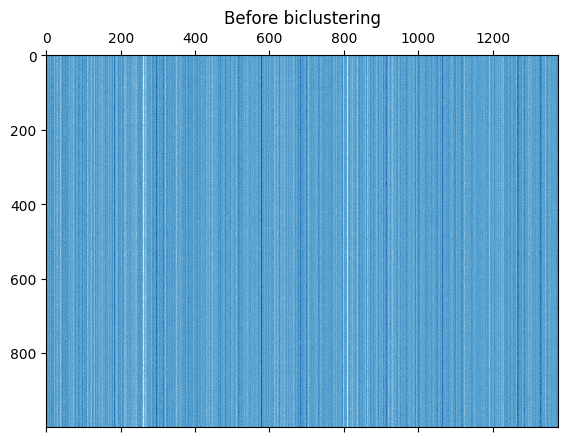

In [82]:
from matplotlib import pyplot as plt
plt.matshow(X, cmap=plt.cm.Blues)
plt.title("Before biclustering")
_ = plt.show()

In [83]:
def min_max_normalize(arr):
    min_vals = arr.min(axis=0)
    max_vals = arr.max(axis=0)
    
    normalized_array = (arr - min_vals) / (max_vals - min_vals)
    return normalized_array

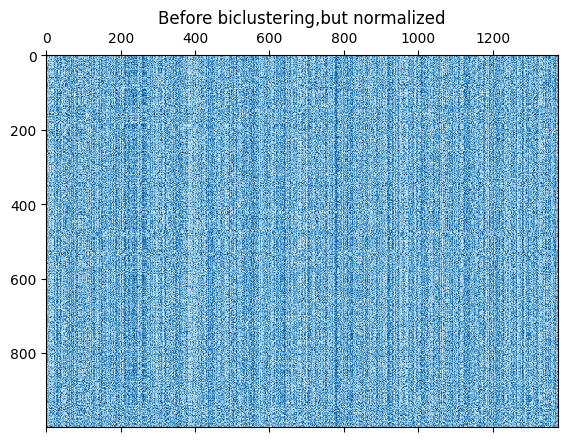

In [84]:
X=min_max_normalize(X)
plt.matshow(X, cmap=plt.cm.Blues)
plt.title("Before biclustering,but normalized")
_ = plt.show()

In [91]:
from sklearn.cluster import SpectralBiclustering

model = SpectralBiclustering(n_clusters=(7,10), random_state=0)
model2 = SpectralBiclustering(n_clusters=(7,10), random_state=1)
model.fit(X)
model2.fit(X)

SpectralBiclustering(n_clusters=(7, 10), random_state=1)

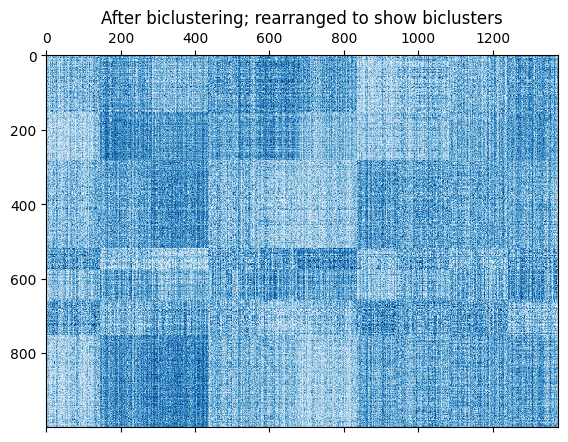

In [92]:

# Reordering first the rows and then the columns.
reordered_rows = X[np.argsort(model.row_labels_)]
reordered_data = reordered_rows[:, np.argsort(model.column_labels_)]

plt.matshow(reordered_data, cmap=plt.cm.Blues)
plt.title("After biclustering; rearranged to show biclusters")
_ = plt.show()

In [93]:
model.column_labels_

array([3, 2, 4, ..., 5, 1, 0])

In [98]:
from sklearn.metrics import consensus_score

# Jaccard score for rows
jaccard= consensus_score(model.biclusters_, model2.biclusters_)

print("Jaccard score:", jaccard)


Jaccard score: 0.9163824439626156
